# Understanding the Violin Plot

A violin plot is a **boxplot with a KDE** mirrored on each side — the width of the violin at any point is proportional to how many observations have that value. It shows the full distribution shape that a boxplot hides.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

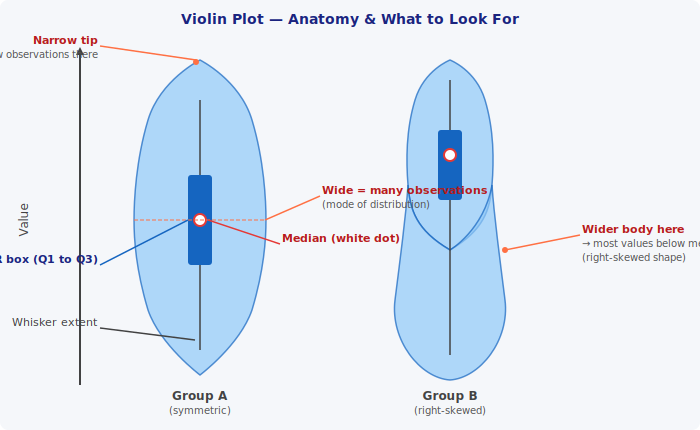

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="430"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="700" height="430" fill="#F5F7FA" rx="8"/>
  <text x="350" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Violin Plot — Anatomy &amp; What to Look For</text>

  <!-- Two violins side by side -->
  <!-- Violin 1 centre: x=200, Violin 2 centre: x=450 -->
  <!-- y range: 55 (top) to 380 (bottom), value axis -->

  <!-- ── Violin 1: roughly symmetric, unimodal ── -->
  <!-- Left half (mirror): cx=200, shape narrows toward top/bottom, widest at y=220 -->
  <path d="M 200,60 C 200,60 160,80 148,120 C 136,160 134,200 134,220
            C 134,240 136,270 148,310 C 160,345 200,375 200,375
            C 200,375 240,345 252,310 C 264,270 266,240 266,220
            C 266,200 264,160 252,120 C 240,80 200,60 200,60 Z"
        fill="#90CAF9" opacity="0.7" stroke="#1565C0" stroke-width="1.5"/>

  <!-- ── Violin 2: right-skewed, wider at bottom ── -->
  <path d="M 450,60 C 450,60 424,70 415,100 C 406,130 406,160 408,185
            C 410,210 416,230 450,250
            C 484,230 490,210 492,185
            C 494,160 494,130 485,100
            C 476,70 450,60 450,60 Z"
        fill="#90CAF9" opacity="0.7" stroke="#1565C0" stroke-width="1.5"/>
  <!-- lower bulge (right-skewed long lower body) -->
  <path d="M 408,185 C 406,215 400,260 395,300 C 390,340 420,378 450,380
            C 480,378 510,340 505,300 C 500,260 494,215 492,185
            C 484,230 450,250 450,250
            C 416,230 410,210 408,185 Z"
        fill="#90CAF9" opacity="0.7" stroke="#1565C0" stroke-width="1.5"/>

  <!-- ── Inner box (IQR) for Violin 1 ── -->
  <rect x="188" y="175" width="24" height="90" fill="#1565C0" rx="3"/>
  <!-- Median dot -->
  <circle cx="200" cy="220" r="6" fill="white" stroke="#E53935" stroke-width="2"/>
  <!-- Whisker -->
  <line x1="200" y1="100" x2="200" y2="175" stroke="#424242" stroke-width="1.5"/>
  <line x1="200" y1="265" x2="200" y2="350" stroke="#424242" stroke-width="1.5"/>

  <!-- ── Inner box for Violin 2 ── -->
  <rect x="438" y="130" width="24" height="70" fill="#1565C0" rx="3"/>
  <circle cx="450" cy="155" r="6" fill="white" stroke="#E53935" stroke-width="2"/>
  <line x1="450" y1="80"  x2="450" y2="130" stroke="#424242" stroke-width="1.5"/>
  <line x1="450" y1="200" x2="450" y2="355" stroke="#424242" stroke-width="1.5"/>

  <!-- Category labels -->
  <text x="200" y="400" text-anchor="middle" font-size="12" font-weight="bold" fill="#424242">Group A</text>
  <text x="200" y="414" text-anchor="middle" font-size="10" fill="#555">(symmetric)</text>
  <text x="450" y="400" text-anchor="middle" font-size="12" font-weight="bold" fill="#424242">Group B</text>
  <text x="450" y="414" text-anchor="middle" font-size="10" fill="#555">(right-skewed)</text>

  <!-- Y axis -->
  <line x1="80" y1="55" x2="80" y2="385" stroke="#424242" stroke-width="2"/>
  <polygon points="76,55 80,47 84,55" fill="#424242"/>
  <text x="28" y="220" text-anchor="middle" font-size="12" fill="#424242"
        transform="rotate(-90 28 220)">Value</text>

  <!-- ── ANNOTATIONS ── -->

  <!-- Width = density annotation on Violin 1 -->
  <!-- Widest point at y=220 -->
  <line x1="134" y1="220" x2="266" y2="220" stroke="#FF7043" stroke-width="1" stroke-dasharray="4,2"/>
  <line x1="265" y1="220" x2="320" y2="196" stroke="#FF7043" stroke-width="1.5"/>
  <text x="322" y="194" font-size="11" font-weight="bold" fill="#B71C1C">Wide = many observations</text>
  <text x="322" y="208" font-size="10" fill="#555">(mode of distribution)</text>

  <!-- Narrow tip -->
  <line x1="196" y1="60" x2="100" y2="46" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="196" cy="62" r="3" fill="#FF7043"/>
  <text x="98" y="44" text-anchor="end" font-size="11" font-weight="bold" fill="#B71C1C">Narrow tip</text>
  <text x="98" y="58" text-anchor="end" font-size="10" fill="#555">few observations there</text>

  <!-- Median dot label -->
  <line x1="208" y1="220" x2="280" y2="244" stroke="#E53935" stroke-width="1.5"/>
  <text x="282" y="242" font-size="11" font-weight="bold" fill="#B71C1C">Median (white dot)</text>

  <!-- IQR box label -->
  <line x1="188" y1="220" x2="100" y2="265" stroke="#1565C0" stroke-width="1.5"/>
  <text x="98" y="263" text-anchor="end" font-size="11" font-weight="bold" fill="#1A237E">IQR box (Q1 to Q3)</text>

  <!-- Whisker -->
  <line x1="195" y1="340" x2="100" y2="328" stroke="#424242" stroke-width="1.5"/>
  <text x="98" y="326" text-anchor="end" font-size="11" fill="#424242">Whisker extent</text>

  <!-- Skew reading -->
  <line x1="505" y1="250" x2="580" y2="235" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="505" cy="250" r="3" fill="#FF7043"/>
  <text x="582" y="233" font-size="11" font-weight="bold" fill="#B71C1C">Wider body here</text>
  <text x="582" y="247" font-size="10" fill="#555">→ most values below median</text>
  <text x="582" y="261" font-size="10" fill="#555">(right-skewed shape)</text>

  <!-- Takeaway -->
  <rect x="80" y="422" width="540" height="0" fill="none"/>
</svg>
"""
display(SVG(_svg))

## Interpreting a Violin Plot

| Feature | What it tells you |
|---|---|
| **Wide belly** | Mode — most observations cluster here |
| **Narrow waist / tips** | Fewer observations in that value range |
| **Two wide bands** | Bimodal — two subpopulations |
| **Asymmetric shape** | Skewed distribution |
| **White dot** | Median |
| **Dark inner box** | IQR (Q1 to Q3) |
| **Thin inner line** | Whiskers (non-outlier range) |
| **Wider body at bottom** | Right-skewed (heavy lower values) |

**Violin vs Boxplot**: boxplot is faster to read for a quick Q1/Q3/median summary; violin shows the full distribution shape. Use both together when presenting results.

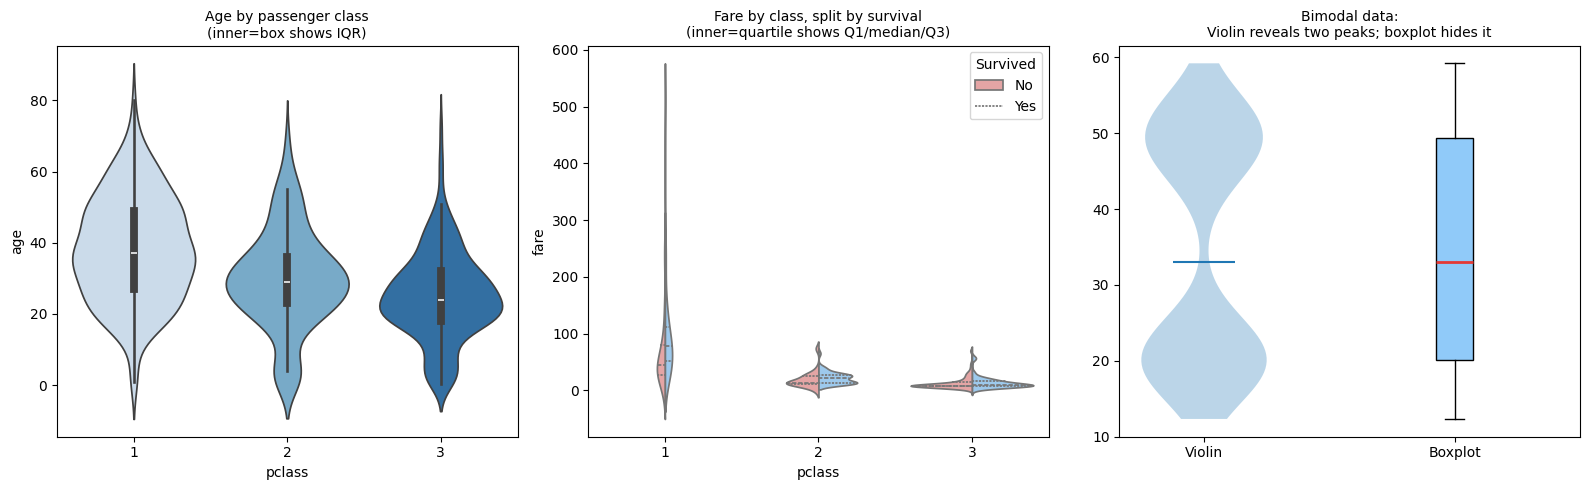

In [3]:
df = sns.load_dataset('titanic')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Basic violin
sns.violinplot(x='pclass', y='age', data=df, ax=axes[0],
               palette='Blues', inner='box')
axes[0].set_title('Age by passenger class\n(inner=box shows IQR)', fontsize=10)

# Split violin: survival within each class
sns.violinplot(x='pclass', y='fare', hue='survived', data=df,
               split=True, ax=axes[1], palette=['#EF9A9A','#90CAF9'],
               inner='quartile')
axes[1].set_title('Fare by class, split by survival\n(inner=quartile shows Q1/median/Q3)', fontsize=10)
axes[1].legend(title='Survived', labels=['No','Yes'])

# Violin vs Boxplot comparison
np.random.seed(0)
bimodal = np.concatenate([np.random.normal(20,3,200), np.random.normal(50,4,200)])
axes[2].violinplot(bimodal, positions=[1], showmedians=True,
                   showextrema=False)
axes[2].boxplot(bimodal, positions=[2], patch_artist=True,
                boxprops=dict(facecolor='#90CAF9'),
                medianprops=dict(color='#E53935', linewidth=2))
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Violin', 'Boxplot'])
axes[2].set_title('Bimodal data:\nViolin reveals two peaks; boxplot hides it', fontsize=10)

plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Showing full distribution shape while comparing groups |
| **Width** | Density — wider = more observations |
| **Bimodal** | Two bulges → visible in violin, invisible in boxplot |
| **Split violin** | Compare two sub-groups within each category |
| **Use with boxplot** | Violin for shape; boxplot for Q1/Q3/outlier reading |